In [3]:
import sys
sys.path.append('../data')


import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from lab_utils_multi import load_house_data
from lab_utils_common import dlc
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

plt.style.use('../data/deeplearning.mplstyle')


In [4]:
X_train,Y_train = load_house_data()

In [5]:
Y_train

array([300.  , 509.8 , 394.  , 540.  , 415.  , 230.  , 560.  , 294.  ,
       718.2 , 200.  , 302.  , 468.  , 374.2 , 388.  , 282.  , 311.8 ,
       401.  , 449.8 , 301.  , 502.  , 340.  , 400.28, 572.  , 264.  ,
       304.  , 298.  , 219.8 , 490.7 , 216.96, 368.2 , 280.  , 526.87,
       237.  , 562.43, 369.8 , 460.  , 374.  , 390.  , 158.  , 426.  ,
       390.  , 277.77, 216.96, 425.8 , 504.  , 329.  , 464.  , 220.  ,
       358.  , 478.  , 334.  , 426.98, 290.  , 463.  , 390.8 , 354.  ,
       350.  , 460.  , 237.  , 288.3 , 282.  , 249.  , 304.  , 332.  ,
       351.8 , 310.  , 216.96, 666.34, 330.  , 480.  , 330.3 , 348.  ,
       304.  , 384.  , 316.  , 430.4 , 450.  , 284.  , 275.  , 414.  ,
       258.  , 378.  , 350.  , 412.  , 373.  , 225.  , 390.  , 267.4 ,
       464.  , 174.  , 340.  , 430.  , 440.  , 216.  , 329.  , 388.  ,
       390.  , 356.  , 257.8 ])

In [6]:
X_features = ['size(sqft)' , 'bedrooms' , 'floor' , 'age']

In [7]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

In [8]:
print("peak   to peak range by column in Raw   X: " , np.ptp(X_train, axis=0) )
print("peak   to peak range by column in Normalized   X: " , np.ptp(X_norm, axis=0) )

peak   to peak range by column in Raw   X:  [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
peak   to peak range by column in Normalized   X:  [5.85 6.14 2.06 3.69]


In [9]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm,Y_train)
print(sgdr)
print(f"Number of iterations completed: {sgdr.n_iter_} , number of weight updates : {sgdr.t_}")

SGDRegressor()
Number of iterations completed: 108 , number of weight updates : 10693.0


In [10]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_

print(f"Model parameters:        w: {w_norm} , b: {b_norm}")
print(f"Model parameters from previous lab :   w: [110.56 -21.27 -32.71 -37.97], b: 363.16]")

Model parameters:        w: [109.92 -20.88 -32.26 -38.12] , b: [363.18]
Model parameters from previous lab :   w: [110.56 -21.27 -32.71 -37.97], b: 363.16]


In [11]:
y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm,w_norm) +b_norm

print(f"Prediction Using np.dot() ans sgdr.predict match :  {(y_pred == y_pred_sgd).all()}")
print(f"Prediction Using np.dot()  :  {y_pred}")
print(f"Prediction Using sgdr.predict  :  { y_pred_sgd}")

Prediction Using np.dot() ans sgdr.predict match :  True
Prediction Using np.dot()  :  [295.14 486.02 389.78 492.18 419.8  222.74 522.72 267.98 683.48 181.75
 318.58 478.77 409.87 393.22 286.58 322.95 406.39 436.74 270.24 499.7
 328.4  388.3  549.49 241.23 295.81 282.31 217.66 490.72 228.28 342.07
 291.52 490.21 238.57 598.33 383.44 453.01 401.24 406.43 172.52 423.83
 434.75 277.39 228.28 448.36 489.1  332.38 465.45 221.75 386.76 456.39
 370.12 468.11 310.6  426.8  391.49 348.3  339.16 471.16 243.65 298.69
 273.   249.85 298.33 334.66 376.42 288.88 228.28 620.71 352.47 510.9
 364.75 363.86 298.33 407.18 288.71 386.6  488.24 261.21 258.33 427.11
 238.53 356.39 340.41 390.01 382.29 220.66 434.75 243.63 465.45 185.75
 342.05 409.6  445.43 232.37 332.38 408.43 406.43 351.66 273.89]
Prediction Using sgdr.predict  :  [295.14 486.02 389.78 492.18 419.8  222.74 522.72 267.98 683.48 181.75
 318.58 478.77 409.87 393.22 286.58 322.95 406.39 436.74 270.24 499.7
 328.4  388.3  549.49 241.23 295.81 

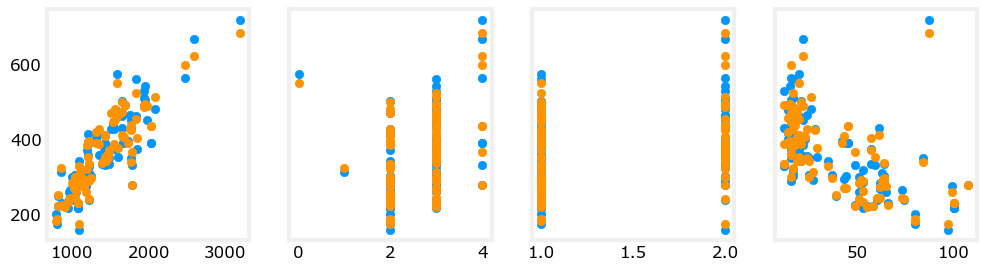

In [12]:
fig, ax = plt.subplots(1,4, figsize= (12,3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], Y_train)
    ax[i].scatter(X_train[:,i],y_pred)